In [1]:
import numpy as np
import pandas as pd # For dataframes (tables)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

!pip install category_encoders
import category_encoders as ce

## Download the code I prepared for you
!wget https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/andrea_models.py
!wget https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/feature_engineering.py

from andrea_models import AndreaLinearRegression # In the course library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.8 MB/s eta 0:00:00
--2025-06-19 14:23:56--  https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/andrea_models.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3190 (3.1K) [text/plain]
Saving to: ‘andrea_models.py’

andrea_models.py    100%[===================>]   3.12K  --.-KB/s    in 0s      

2025-06-19 14:23:56 (54.5 MB/s) - ‘andrea_models.py’ saved [3190/3190]

--2025-06-19 14:23:56--  https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/feature_engineering.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githu

In [2]:
! wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_test.csv

--2025-06-19 14:24:24--  https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 308116 (301K) [text/plain]
Saving to: ‘X_test.csv’

X_test.csv          100%[===================>] 300.89K  --.-KB/s    in 0.04s   

2025-06-19 14:24:25 (6.81 MB/s) - ‘X_test.csv’ saved [308116/308116]



In [3]:
! wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/y_train.csv

--2025-06-19 14:24:25--  https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/y_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 136635 (133K) [text/plain]
Saving to: ‘y_train.csv’

y_train.csv         100%[===================>] 133.43K  --.-KB/s    in 0.03s   

2025-06-19 14:24:26 (4.99 MB/s) - ‘y_train.csv’ saved [136635/136635]



In [4]:
! wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_train.csv

--2025-06-19 14:24:27--  https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 927653 (906K) [text/plain]
Saving to: ‘X_train.csv’

X_train.csv         100%[===================>] 905.91K  --.-KB/s    in 0.06s   

2025-06-19 14:24:27 (15.3 MB/s) - ‘X_train.csv’ saved [927653/927653]



In [5]:
df_X_train = pd.read_csv("X_train.csv", index_col=0)
df_X_test = pd.read_csv("X_test.csv", index_col=0)
df_y_train = pd.read_csv("y_train.csv", index_col=0)

In [6]:
df_X_train.head()

,Identifiant,ft_2_categ,EXPO,ft_4_categ,ft_5_categ,ft_6_categ,ft_7_categ,ft_8_categ,ft_9_categ,ft_10_categ,...,ft_16_categ,ft_17_categ,ft_18_categ,ft_19_categ,superficief,ft_21_categ,ft_22_categ,ft_23_categ,ft_24_categ,Insee
0,18702,2014,1,0,V,N,1,O,1,O,...,IDENTIQUE,V,base,2,1351.0,4,2012.0,0.0,2,65440
1,3877,2014,1,0,V,V,V,V,V,V,...,V,N,base,2,1972.0,2,1980.0,0.0,.,14341
2,4942,2013,1,1,V,V,V,V,V,V,...,V,N,base,2,1630.0,4,NaN,0.0,.,75109
3,13428,2013,"0,246575342",0,N,V,V,V,V,V,...,V,N,base,2,532.0,3,NaN,0.0,.,92004
4,17137,2015,1,0,V,N,2,O,1,O,...,IDENTIQUE,V,base,2,1050.0,2,1972.0,0.0,4,59340


In [7]:
# Fusionner X et y sur 'Identifiant'
df_train = df_X_train.merge(df_y_train, on="Identifiant")
df_train.head()

,Identifiant,ft_2_categ,EXPO,ft_4_categ,ft_5_categ,ft_6_categ,ft_7_categ,ft_8_categ,ft_9_categ,ft_10_categ,...,ft_17_categ,ft_18_categ,ft_19_categ,superficief,ft_21_categ,ft_22_categ,ft_23_categ,ft_24_categ,Insee,target
0,18702,2014,1,0,V,N,1,O,1,O,...,V,base,2,1351.0,4,2012.0,0.0,2,65440,0
1,3877,2014,1,0,V,V,V,V,V,V,...,N,base,2,1972.0,2,1980.0,0.0,.,14341,1
2,4942,2013,1,1,V,V,V,V,V,V,...,N,base,2,1630.0,4,NaN,0.0,.,75109,0
3,13428,2013,"0,246575342",0,N,V,V,V,V,V,...,N,base,2,532.0,3,NaN,0.0,.,92004,0
4,17137,2015,1,0,V,N,2,O,1,O,...,V,base,2,1050.0,2,1972.0,0.0,4,59340,0


In [8]:
df_train = df_train.drop(labels=['Identifiant', 'ft_2_categ', 'ft_22_categ', 'Insee', 'ft_4_categ', 'ft_5_categ', 'ft_6_categ', 'ft_7_categ', 'ft_8_categ', 'ft_9_categ', 'ft_10_categ', 'ft_11_categ', 'ft_12_categ', 'ft_13_categ', 'ft_14_categ', 'ft_15_categ', 'ft_16_categ', 'ft_17_categ', 'ft_18_categ', 'ft_19_categ', 'ft_21_categ', 'ft_23_categ', 'ft_24_categ'], axis=1)

In [9]:
df_train.head()

,EXPO,superficief,target
0,1,1351.0,0
1,1,1972.0,1
2,1,1630.0,0
3,"0,246575342",532.0,0
4,1,1050.0,0


In [10]:
# Nettoyage des données (corriger les virgules, convertir en float)

df_train_cleaned = df_train.copy()
df_train_cleaned['EXPO'] = df_train_cleaned['EXPO'].str.replace(',', '.').astype(float)
for col in df_train_cleaned.columns:
    if df_train_cleaned[col].dtype == 'object':
        df_train_cleaned[col] = df_train_cleaned[col].str.replace(',', '.', regex=False)
        try:
            df_train_cleaned[col] = df_train_cleaned[col].astype(float)
        except:
            pass

df_X_test_cleaned = df_X_test.copy()
df_X_test_cleaned['EXPO'] = df_X_test_cleaned['EXPO'].str.replace(',', '.').astype(float)
for col in df_X_test_cleaned.columns:
    if df_X_test_cleaned[col].dtype == 'object':
        df_X_test_cleaned[col] = df_X_test_cleaned[col].str.replace(',', '.', regex=False)
        try:
            df_X_test_cleaned[col] = df_X_test_cleaned[col].astype(float)
        except:
            pass

In [11]:
# Supprimer les lignes avec des NaN
df_train_cleaned = df_train_cleaned.dropna()
df_X_test_cleaned = df_X_test_cleaned.dropna()

In [12]:
X = df_train_cleaned.drop(labels='target', axis=1)
y = df_train_cleaned['target']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,
                                        shuffle=True, random_state=4)

Linear regression on the original dataset

In [13]:
model = AndreaLinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MSE = mean_squared_error(y_test, y_pred)
RMSE = math.sqrt(MSE)
RMSE

0.39347220456396725

Linear regression on the reduced dataset

In [14]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sca = scaler.transform(X_train)

In [15]:
U,Sigma,Vt = np.linalg.svd(X_train_sca)

Text(0.5, 1.0, 'Normalized variance explained of X_train')

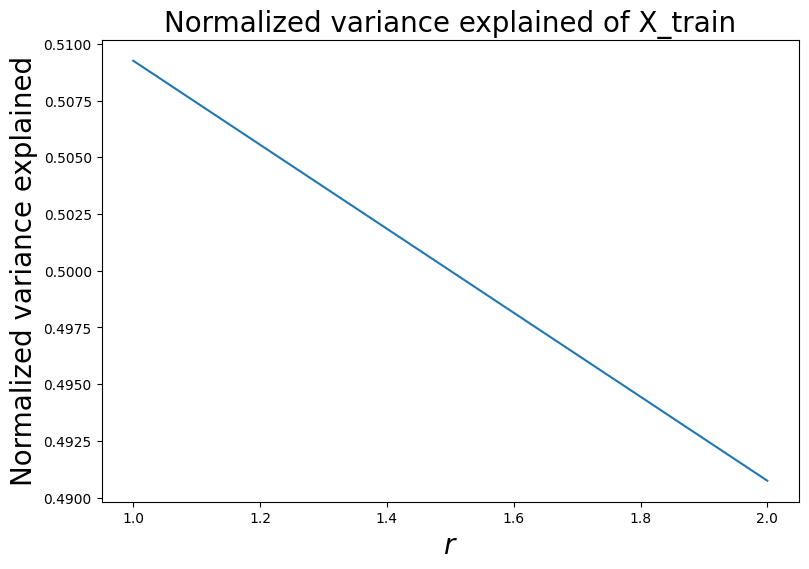

In [26]:
Sigma_squared = np.square(Sigma)
total_variance = sum(Sigma_squared)

### Plotting
fig = plt.figure(figsize=(9,6))
plt.plot(range(1,1+len(Sigma_squared)),Sigma_squared/total_variance)
plt.xlabel(r'$r$',size=20)
plt.ylabel(r'Normalized variance explained',size=20)
plt.title(r'Normalized variance explained of X_train',size=20)

Text(0.5, 1.0, 'Cumulative normalized variance explained of X_train')

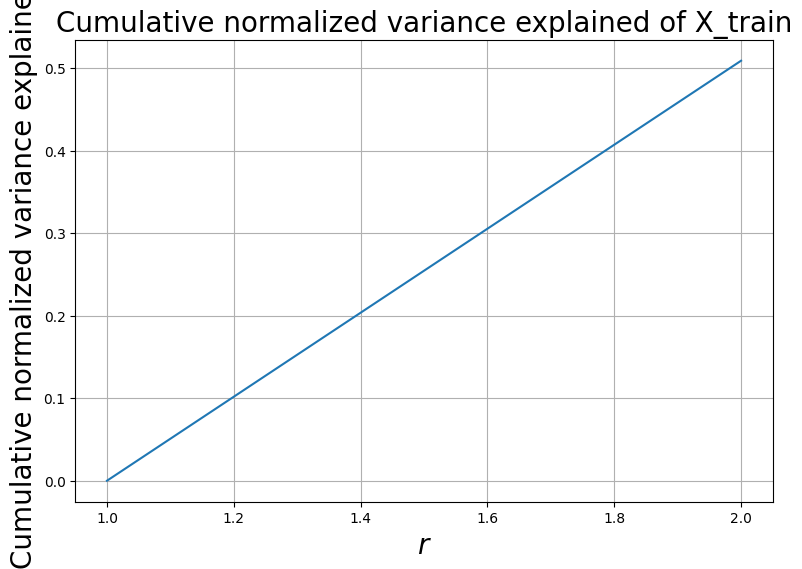

In [17]:


cumul = [ sum(Sigma_squared[0:i]/total_variance) for i in range(len(Sigma_squared))]

### Plotting
fig = plt.figure(figsize=(9,6))
plt.plot(range(1,1+len(cumul)),cumul)
plt.xlabel(r'$r$',size=20)
plt.ylabel(r'Cumulative normalized variance explained',size=20)
plt.grid(visible=True)
plt.title(r'Cumulative normalized variance explained of X_train',size=20)



In [28]:
r = 2

In [29]:
V = Vt.T  # We are interested in V (while the Vt given by linalg.svd was
          # the transpose of V)
V_r = V[:, :r] # Take the first k columns
X_train_reduced = X_train_sca.dot(V_r)

In [30]:
model = AndreaLinearRegression()
model.fit(X_train_reduced, y_train)

AndreaLinearRegression()

In [31]:
X_test_sca = scaler.transform(X_test)
X_test_reduced = X_test_sca.dot (V_r)

In [32]:
y_pred = model.predict(X_test_reduced)

MSE = mean_squared_error(y_test, y_pred)
RMSE = math.sqrt(MSE)
RMSE

0.3934722045639665

In [39]:
from collections import Counter
from imblearn.over_sampling import SMOTE

print( "Samples per class before SMOTE: ", Counter(y_train) )

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

print( "Samples per class after SMOTE: ", Counter(y_train) )

Samples per class before SMOTE:  Counter({0: 5433, 1: 1644})
Samples per class after SMOTE:  Counter({1: 5433, 0: 5433})


In [41]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss

model = RandomForestClassifier(n_estimators=100,
                      criterion='gini',
                      max_leaf_nodes=16, # Each tree cannot have more than that
                      random_state=5, # For reproducibility
                      n_jobs=-1, # Use all the CPUs
                      )

model.fit(X_train, y_train)

RandomForestClassifier(max_leaf_nodes=16, n_jobs=-1, random_state=5)

In [42]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sca = scaler.transform(X_train)

In [43]:
U,Sigma,Vt = np.linalg.svd(X_train_sca)

Text(0.5, 1.0, 'Normalized variance explained of X_train')

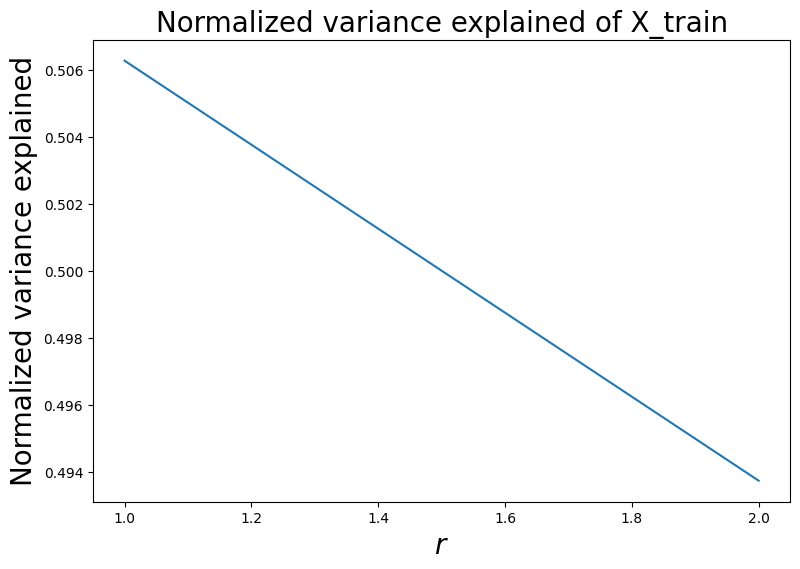

In [44]:
Sigma_squared = np.square(Sigma)
total_variance = sum(Sigma_squared)

### Plotting
fig = plt.figure(figsize=(9,6))
plt.plot(range(1,1+len(Sigma_squared)),Sigma_squared/total_variance)
plt.xlabel(r'$r$',size=20)
plt.ylabel(r'Normalized variance explained',size=20)
plt.title(r'Normalized variance explained of X_train',size=20)